In [1]:
# Install dependencies if not already present
try:
    import albumentations
    import ultralytics
except ImportError:
    !pip install ultralytics albumentations opencv-python-headless

import os
import shutil
import random
import math
import cv2
import numpy as np
import albumentations as A
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
DATASET_DIR = "/kaggle/input/datasets/akitsuyoshi/tictactoe-with-real/tictactoe_with_nagative"

yaml_content = f"""
path: {os.path.abspath(DATASET_DIR)}
train: images/train
val: images/valid 

nc: 3
names: ['O', 'X', 'table']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print("data.yaml configuration file created successfully in /kaggle/working/")

data.yaml configuration file created successfully in /kaggle/working/


In [3]:
custom_transforms = [
    A.OneOf(
        [
            A.MotionBlur(blur_limit=7, p=1.0),
            A.MedianBlur(blur_limit=7, p=1.0),
            A.GaussianBlur(blur_limit=7, p=1.0),
        ],
        p=0.15,
    ),
    A.OneOf(
        [
            A.GaussNoise(std_range=(0.01, 0.03), p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.3), p=1.0),
        ],
        p=0.1,
    ),
    A.RandomGamma(gamma_limit=(85, 120), p=0.15),
    A.CLAHE(clip_limit=(1,3), p=0.1),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(0.03, 0.08),
        hole_width_range=(0.03, 0.08),
        fill=0,
        p=0.3,
    ),
]

train_args = {
    "data": "/kaggle/working/data.yaml",
    "patience": 15,
    "imgsz": 640,
    "batch": 32,
    "device": 0,
    "augmentations": custom_transforms,
    "degrees": 5.0,
    "shear": 3.0,
    "translate": 0.1,
    "scale": 0.25,
    "perspective": 0.001,
    "fliplr": 0.25,
    "flipud": 0.1,
    "mosaic": 0.0,
    "mixup": 0.0,
    "workers": 4,
    "plots": True,
    "cos_lr": True,
    "warmup_epochs": 5,
}

In [4]:
model = YOLO("yolo11n.pt")

model.train(
    **train_args,
    epochs=100,
    freeze=4,
    name="stage1",
    exist_ok=True,
)

model.export(format="onnx")

print("Training process complete! Check your 'runs/detect/train' directory for weights.")

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[OneOf([
  MotionBlur(p=1.0, allow_shifted=True, angle_range=(0.0, 360.0), blur_limit=(3, 7), direction_range=(-1.0, 1.0)),
  MedianBlur(p=1.0, blur_limit=(3, 7)),
  GaussianBlur(p=1.0, blur_limit=(0, 7), sigma_limit=(0.5, 3.0)),
], p=0.15), OneOf([
  GaussNoise(p=1.0, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.01, 0.03)),
  ISONoise(p=1.0, color_shift=(0.01, 0.05), intensity=(0.1, 0.3)),
], p=0.1), RandomGamma(p=0.15, gamma_limit=(85.0, 120.0)), CLAHE(p=0.1, clip_limit=(1.0, 3.0), tile_grid_size=(8, 8)), RandomBrightnessContrast(p=0.3, brightness_by_max=True, brightness_limit=(-0.3, 0.3), contrast_limit=(-0.3, 0.3), ensure_safe_range=False), CoarseDropout(p=0.3, fill=0.0, fill_mask=None, hole_height_range=(0.03, 0.08), hole_width_range=(0.03, 0.08), num_holes_range=(1, 4))], auto_aug

In [5]:
# 1. Path to the trained weights
WEIGHTS_PATH = "/kaggle/working/runs/detect/stage1/weights/best.pt"

# Fallback to base weights if you are just testing the script structure without real training
if not os.path.exists(WEIGHTS_PATH):
    print(f"⚠️ Trained weights not found at {WEIGHTS_PATH}. Using default 'yolo11n.pt' for structural test.")
    WEIGHTS_PATH = "yolo11n.pt"

# 2. Load the trained model
model = YOLO(WEIGHTS_PATH)

🔍 Found 10 images.


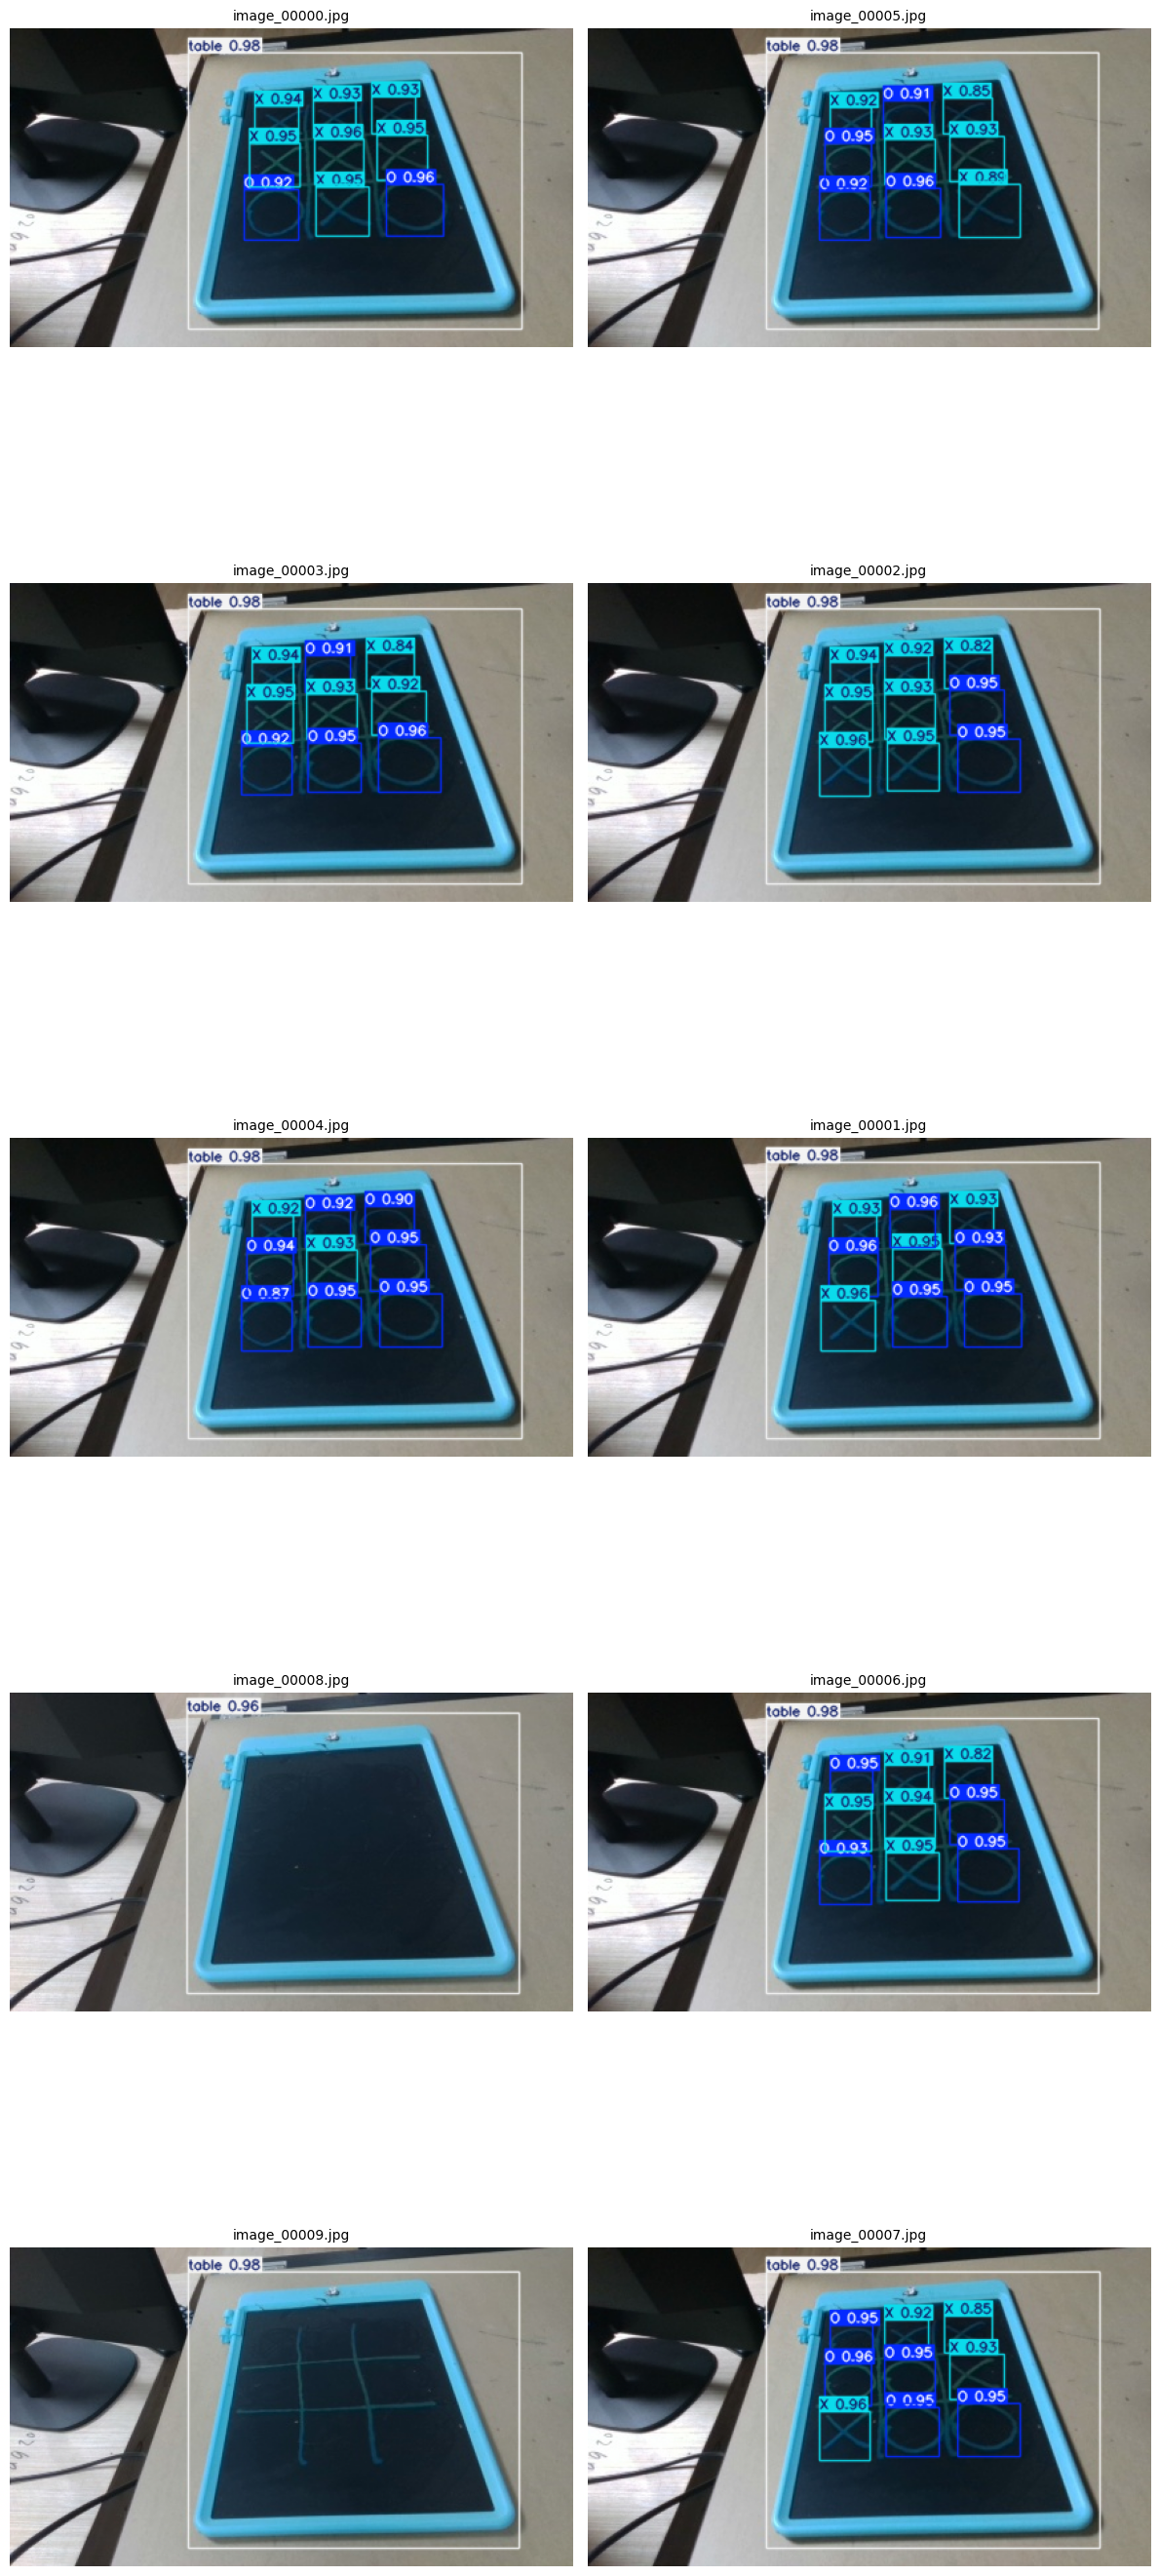

✅ Saved to: /kaggle/working/prediction_grid.png


In [6]:
import glob

test_images = glob.glob("/kaggle/input/datasets/akitsuyoshi/tictactoe-with-real/tictactoe_with_nagative/images/test/*.jpg")
test_images = random.sample(test_images, min(10, len(test_images)))

if not test_images:
    print("❌ No test images found.")
else:
    print(f"🔍 Found {len(test_images)} images.")

    annotated_images = []

    # Predict
    for img_path in test_images[:10]:
        result = model.predict(
            source=img_path,
            conf=0.25,
            verbose=False
        )[0]

        annotated = result.plot(
            font_size=1,
            line_width=1
        )

        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        annotated_images.append(
            (os.path.basename(img_path), annotated)
        )

    # Create grid
    cols = 2
    rows = math.ceil(len(annotated_images) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 6))

    # Handle the case of a single row
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, (name, img) in zip(axes, annotated_images):
        ax.imshow(img)
        ax.set_title(name, fontsize=10)

    plt.tight_layout()

    save_path = "/kaggle/working/prediction_grid.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"✅ Saved to: {save_path}")